In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import math
from numpy.linalg import eigh

In [ ]:
df = pd.read_csv("dane/dane_2D_7.txt", sep=r"\s+", header=None, names=["x", "y", "class"])
X = df[["x", "y"]].values
true_classes = df["class"].values
n_clusters = len(np.unique(true_classes))

In [15]:
class KMeansPP:
    def __init__(self, n_clusters, max_iters=100, tol=1e-6, random_state=None):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        if random_state is not None:
            np.random.seed(random_state)
        self.centroids = None
        self.labels_ = None

    def _initialize_centroids(self, X):
        m = X.shape[0]
        first_idx = np.random.randint(m)
        centroids = [X[first_idx]]

        for _ in range(1, self.n_clusters):
            distances_sq = []
            for i in range(m):
                x = X[i]
                min_dist_sq = float("inf")
                for c in centroids:
                    dist_sq = np.sum((x - c) ** 2)
                    if dist_sq < min_dist_sq:
                        min_dist_sq = dist_sq
                distances_sq.append(min_dist_sq)

            distances_sq = np.array(distances_sq)
            probabilities = distances_sq / distances_sq.sum()
            next_idx = np.random.choice(m, p=probabilities)
            centroids.append(X[next_idx])

        return np.stack(centroids)

    def _assign_labels(self, X):
        m = X.shape[0]
        labels = np.zeros(m, dtype=int)
        for i in range(m):
            dists_sq = np.sum((X[i] - self.centroids) ** 2, axis=1)
            labels[i] = np.argmin(dists_sq)
        return labels

    def _update_centroids(self, X, labels):
        n_features = X.shape[1]
        new_centroids = np.zeros((self.n_clusters, n_features))

        for k in range(self.n_clusters):
            members = X[labels == k]
            if len(members) > 0:
                new_centroids[k] = members.mean(axis=0)
            else:
                rand_idx = np.random.randint(X.shape[0])
                new_centroids[k] = X[rand_idx]

        return new_centroids

    def fit(self, X):
        self.centroids = self._initialize_centroids(X)

        for _ in range(self.max_iters):
            labels = self._assign_labels(X)
            new_centroids = self._update_centroids(X, labels)

            shifts = np.sqrt(np.sum((new_centroids - self.centroids) ** 2, axis=1))
            if np.max(shifts) < self.tol:
                break

            self.centroids = new_centroids

        self.labels_ = self._assign_labels(X)

    def predict(self, X):
        m = X.shape[0]
        predictions = np.zeros(m, dtype=int)
        for i in range(m):
            dists_sq = np.sum((X[i] - self.centroids) ** 2, axis=1)
            predictions[i] = np.argmin(dists_sq)
        return predictions

In [5]:
kmeans = KMeansPP(n_clusters=n_clusters, max_iters=300, tol=1e-6, random_state=42)
kmeans.fit(X)
pred_labels = kmeans.labels_
centroids = kmeans.centroids

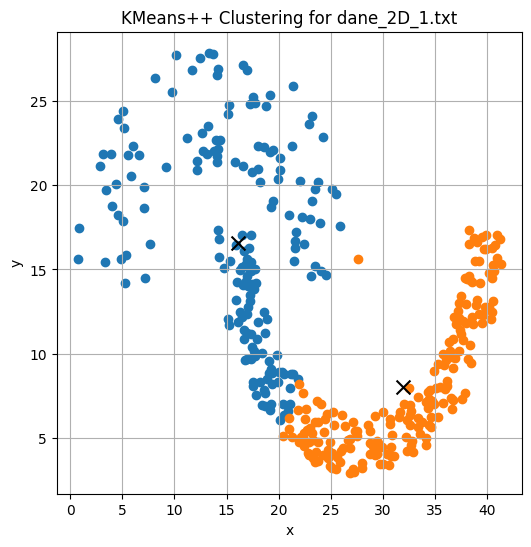

In [ ]:
plt.figure(figsize=(6, 6))
for cluster_id in range(n_clusters):
    pts = X[pred_labels == cluster_id]
    plt.scatter(pts[:, 0], pts[:, 1], label=f"Cluster {cluster_id}")
plt.scatter(
    centroids[:, 0], centroids[:, 1], c="black", marker="x", s=100, label="Centroids"
)
plt.title("KMeans++ Clustering for dane_2D_1.txt")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [ ]:
class KMeansPPKernel:
    def __init__(
        self,
        n_clusters,
        max_iters=100,
        tol=1e-6,
        kernel="rbf",
        gamma=None,
        degree=3,
        coef0=1.0,
        random_state=None,
    ):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.kernel = kernel
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0
        if random_state is not None:
            np.random.seed(random_state)
        self.labels_ = None
        self.K = None
        self.S = None
        self.T = None

    def _build_kernel(self, X):
        n_samples, n_features = X.shape
        if self.kernel == "linear":
            return X.dot(X.T)
        if self.kernel == "rbf":
            if self.gamma is None:
                self.gamma = 1.0 / n_features
            sq_dists = cdist(X, X, metric="sqeuclidean")
            return np.exp(-self.gamma * sq_dists)
        if self.kernel == "poly":
            if self.gamma is None:
                self.gamma = 1.0 / n_features
            gram = X.dot(X.T)
            return (self.gamma * gram + self.coef0) ** self.degree
        if self.kernel == "sigmoid":
            if self.gamma is None:
                self.gamma = 1.0 / n_features
            gram = X.dot(X.T)
            return np.tanh(self.gamma * gram + self.coef0)
        raise ValueError(f"Unsupported kernel: {self.kernel}")

    def _initialize_labels(self, n):
        return np.random.randint(0, self.n_clusters, size=n)

    def fit(self, X):
        n = X.shape[0]
        self.K = self._build_kernel(X)
        labels = self._initialize_labels(n)
        self.S = np.zeros((self.n_clusters, n))
        self.T = np.zeros(self.n_clusters)
        for k in range(self.n_clusters):
            idx = np.where(labels == k)[0]
            if idx.size > 0:
                self.S[k, :] = np.sum(self.K[:, idx], axis=1)
                self.T[k] = np.sum(self.K[np.ix_(idx, idx)])
        for _ in range(self.max_iters):
            old = labels.copy()
            sizes = np.bincount(labels, minlength=self.n_clusters)
            diag = np.diag(self.K)
            D = np.zeros((self.n_clusters, n))
            for k in range(self.n_clusters):
                if sizes[k] > 0:
                    a = 2.0 / sizes[k]
                    b = 1.0 / (sizes[k] ** 2)
                    D[k, :] = diag - a * self.S[k, :] + b * self.T[k]
                else:
                    D[k, :] = np.inf
            labels = np.argmin(D, axis=0)
            changed = np.sum(labels != old) / n
            if changed < self.tol:
                break
            self.S[:] = 0
            self.T[:] = 0
            for k in range(self.n_clusters):
                idx = np.where(labels == k)[0]
                if idx.size > 0:
                    self.S[k, :] = np.sum(self.K[:, idx], axis=1)
                    self.T[k] = np.sum(self.K[np.ix_(idx, idx)])
        self.labels_ = labels

    def predict(self, X_new, X_train=None):
        return self.labels_

In [8]:
def compute_medoid_centroids(K, labels, X):
    centroids = []
    for k in np.unique(labels):
        idx = np.where(labels == k)[0]
        K_sub = K[np.ix_(idx, idx)]
        sums = np.sum(K_sub, axis=1)
        best = idx[np.argmax(sums)]
        centroids.append(X[best])
    return np.vstack(centroids)

In [ ]:
configs = [
    ("linear", {}),
    ("rbf", {"gamma": 0.05}),
    ("sigmoid", {"gamma": 0.02, "coef0": 0.06}),
]

for degree in range(2, 6):
    configs.append(("poly", {"gamma": 0.5, "degree": degree, "coef0": 1.0}))

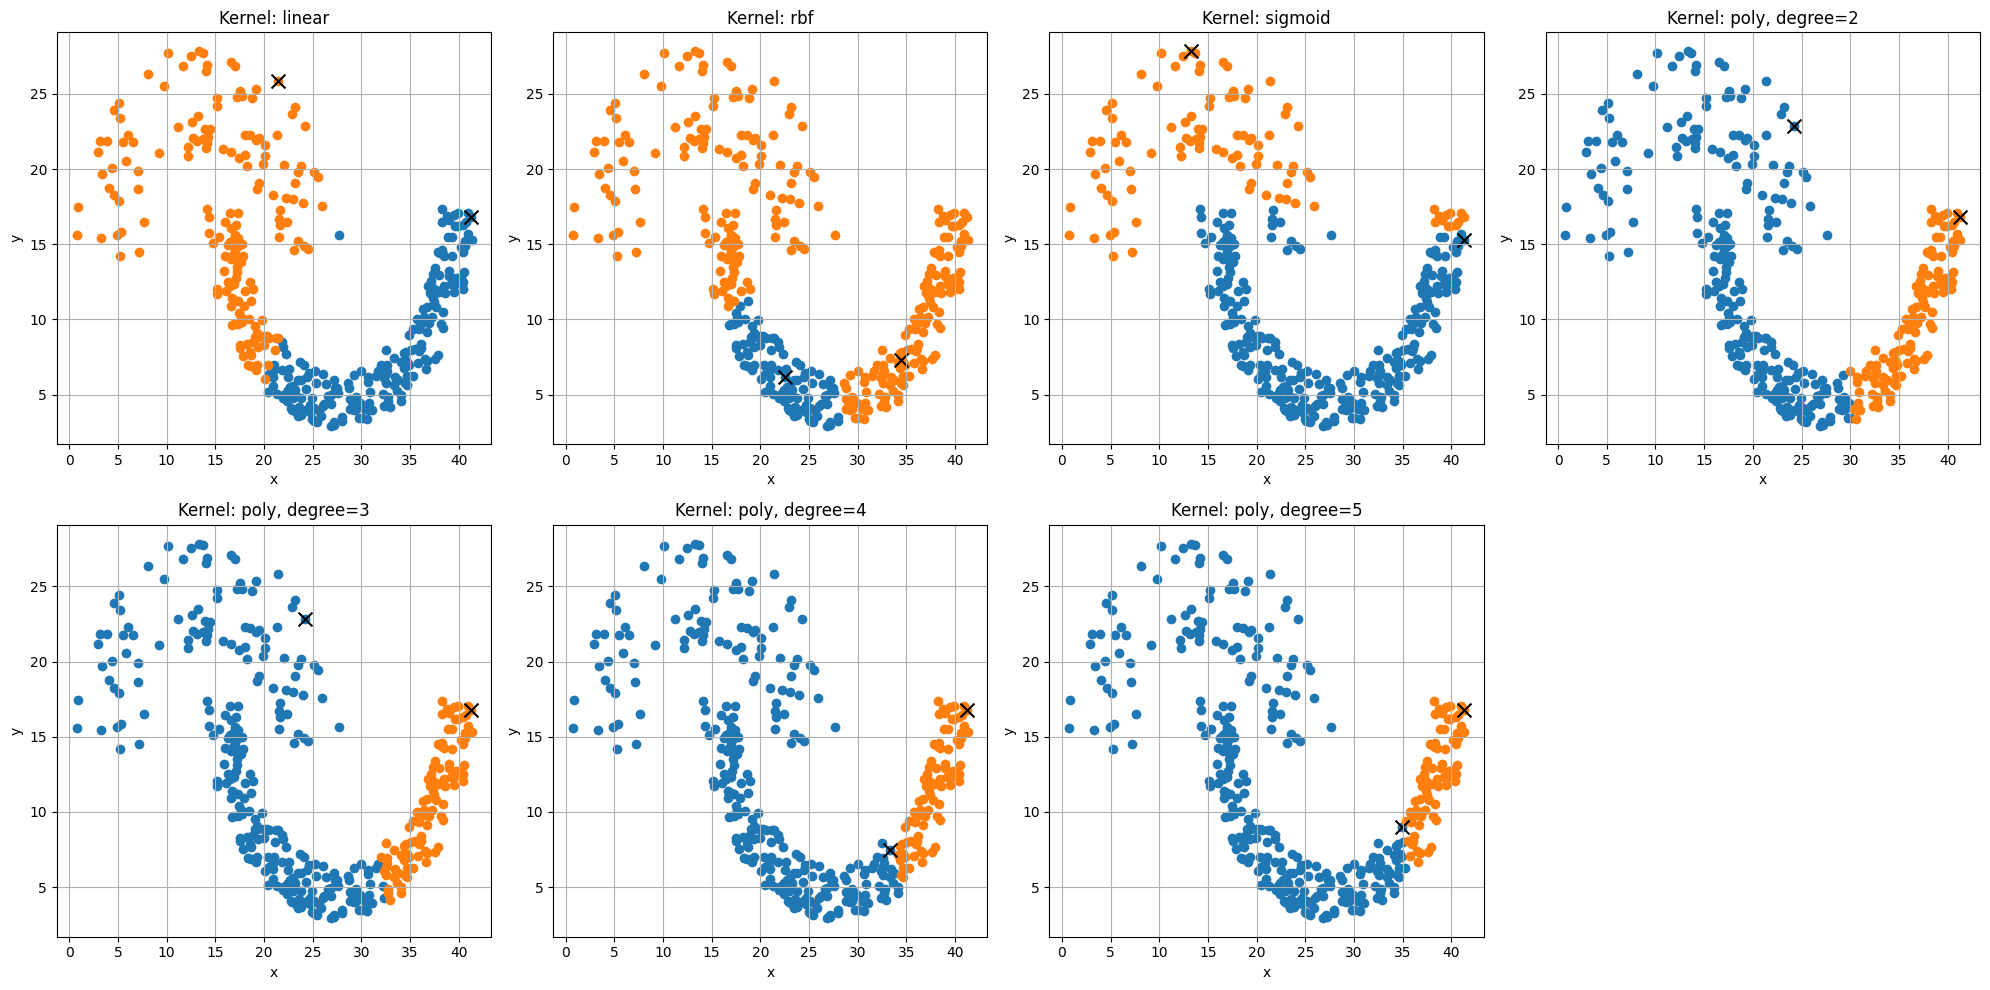

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (kernel, params) in enumerate(configs):
    model = KMeansPPKernel(
        n_clusters=n_clusters,
        max_iters=300,
        tol=1e-6,
        kernel=kernel,
        gamma=params.get("gamma"),
        degree=params.get("degree", 3),
        coef0=params.get("coef0", 1.0),
        random_state=42,
    )
    model.fit(X)
    labels = model.labels_
    centroids_medoid = compute_medoid_centroids(model.K, labels, X)

    ax = axes[i]
    for k in range(n_clusters):
        pts = X[labels == k]
        ax.scatter(pts[:, 0], pts[:, 1], label=f"Cluster {k}")
    ax.scatter(
        centroids_medoid[:, 0],
        centroids_medoid[:, 1],
        c="black",
        marker="x",
        s=100,
        label="Centroids",
    )
    if kernel == "poly":
        ax.set_title(f'Kernel: {kernel}, degree={params["degree"]}')
    else:
        ax.set_title(f"Kernel: {kernel}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.grid(True)

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [25]:
def clustering_error(true_labels, pred_labels):
    true_labels = np.asarray(true_labels)
    pred_labels = np.asarray(pred_labels)
    unique_preds = np.unique(pred_labels)

    mapping = {}
    for p in unique_preds:
        mask = pred_labels == p
        true_in_cluster = true_labels[mask]

        if true_in_cluster.size == 0:
            continue

        labels, counts = np.unique(true_in_cluster, return_counts=True)
        most_common = labels[np.argmax(counts)]
        mapping[p] = most_common

    correct = 0
    for idx, pl in enumerate(pred_labels):
        mapped_label = mapping.get(pl, None)
        if mapped_label is not None and true_labels[idx] == mapped_label:
            correct += 1

    total = true_labels.shape[0]
    error = 1.0 - (correct / total)
    return error

In [ ]:
for n in range(1, 9):
    filename = f"dane/dane_2D_{n}.txt"
    df = pd.read_csv(filename, sep=r"\s+", header=None, names=["x", "y", "class"])
    X = df[["x", "y"]].values
    true_classes = df["class"].values
    n_clusters = len(np.unique(true_classes))

    configs = [
        ("linear", {}),
        ("rbf", {"gamma": 0.05}),
        ("sigmoid", {"gamma": 0.02, "coef0": 0.06}),
    ]
    for degree in range(2, 6):
        configs.append(("poly", {"gamma": 0.5, "degree": degree, "coef0": 1.0}))

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()

    for i, (kernel, params) in enumerate(configs):
        model = KMeansPPKernel(
            n_clusters=n_clusters,
            max_iters=300,
            tol=1e-6,
            kernel=kernel,
            gamma=params.get("gamma"),
            degree=params.get("degree", 3),
            coef0=params.get("coef0", 1.0),
            random_state=42,
        )
        model.fit(X)
        labels = model.labels_
        centroids_medoid = compute_medoid_centroids(model.K, labels, X)

        err = clustering_error(true_classes, labels)

        ax = axes[i]
        for k in range(n_clusters):
            pts = X[labels == k]
            ax.scatter(pts[:, 0], pts[:, 1], label=f"Cluster {k}")
        ax.scatter(
            centroids_medoid[:, 0],
            centroids_medoid[:, 1],
            c="black",
            marker="x",
            s=100,
            label="Centroids",
        )

        if kernel == "poly":
            ax.set_title(f'Kernel: {kernel}, deg={params["degree"]}\n' f"Err={err:.3f}")
        else:
            ax.set_title(f"Kernel: {kernel}\n" f"Err={err:.3f}")

        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.grid(True)

        print(
            f"dane_2D_{n} | kernel={kernel}"
            + (f', degree={params["degree"]}' if kernel == "poly" else "")
            + f" Classification error rate: {err:.4f}"
        )

    axes[-1].axis("off")

    plt.suptitle(f"Kernel KMeans++ dla dane_2D_{n}.txt", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_filename = f"kmeanpp_dane_2D_{n}.png"
    plt.savefig(output_filename)
    plt.close()
    print(f"Saved: {output_filename}")

dane_2D_1 | kernel=linear Classification error rate: 0.1472
dane_2D_1 | kernel=rbf Classification error rate: 0.1459
dane_2D_1 | kernel=sigmoid Classification error rate: 0.6104
dane_2D_1 | kernel=poly, degree=2 Classification error rate: 0.0964
dane_2D_1 | kernel=poly, degree=3 Classification error rate: 0.1371
dane_2D_1 | kernel=poly, degree=4 Classification error rate: 0.2030
dane_2D_1 | kernel=poly, degree=5 Classification error rate: 0.3046
Saved: kmeanpp_dane_2D_1.png
dane_2D_2 | kernel=linear Classification error rate: 0.2657
dane_2D_2 | kernel=rbf Classification error rate: 0.1679
dane_2D_2 | kernel=sigmoid Classification error rate: 0.6040
dane_2D_2 | kernel=poly, degree=2 Classification error rate: 0.2206
dane_2D_2 | kernel=poly, degree=3 Classification error rate: 0.2180
dane_2D_2 | kernel=poly, degree=4 Classification error rate: 0.2206
dane_2D_2 | kernel=poly, degree=5 Classification error rate: 0.3534
Saved: kmeanpp_dane_2D_2.png
dane_2D_3 | kernel=linear Classification e

In [ ]:
df_rp = pd.read_csv(
    "dane/rp.data",
    header=None,
    sep=r"\s+",
    names=[f"f{i}" for i in range(1, 10)] + ["class"],
)

X_rp = df_rp.iloc[:, :-1].values
true_classes_rp = df_rp["class"].values
n_clusters_rp = len(np.unique(true_classes_rp))

configs_rp = [
    ("linear", {}),
    ("rbf", {"gamma": 0.05}),
    ("sigmoid", {"gamma": 0.02, "coef0": 0.06}),
]
for degree in range(2, 6):
    configs_rp.append(("poly", {"gamma": 0.5, "degree": degree, "coef0": 1.0}))

for kernel_name, params in configs_rp:
    model = KMeansPPKernel(
        n_clusters=n_clusters_rp,
        max_iters=300,
        tol=1e-6,
        kernel=kernel_name,
        gamma=params.get("gamma", None),
        degree=params.get("degree", 3),
        coef0=params.get("coef0", 1.0),
        random_state=42,
    )
    model.fit(X_rp)
    labels_pred = model.labels_
    error_rate = clustering_error(true_classes_rp, labels_pred)
    print(f"Kernel: {kernel_name:7s}  Classification error rate: {error_rate:.2%}")

Kernel: linear   Classification error rate: 3.81%
Kernel: rbf      Classification error rate: 6.00%
Kernel: sigmoid  Classification error rate: 2.64%
Kernel: poly     Classification error rate: 7.17%
Kernel: poly     Classification error rate: 15.37%
Kernel: poly     Classification error rate: 20.06%
Kernel: poly     Classification error rate: 29.28%


In [ ]:
df18 = pd.read_csv("dane/data_18D.txt", sep=r"\s+", header=None)
X18 = df18.values

In [ ]:
configs_rp = [
    ("linear", {}),
    ("rbf", {"gamma": 0.05}),
    ("sigmoid", {"gamma": 0.02, "coef0": 0.06}),
]
for degree in range(2, 6):
    configs_rp.append(("poly", {"gamma": 0.5, "degree": degree, "coef0": 1.0}))

In [ ]:
max_k = 10
kernel_J = {}

for kernel_name, params in configs_rp:
    J_vals = []
    print(f"\nKernel: {kernel_name}", end="")
    if kernel_name == "poly":
        print(f', degree={params["degree"]}')
    else:
        print()

    for k in range(1, max_k + 1):
        model = KMeansPPKernel(
            n_clusters=k,
            max_iters=300,
            tol=1e-6,
            kernel=kernel_name,
            gamma=params.get("gamma", None),
            degree=params.get("degree", 3),
            coef0=params.get("coef0", 1.0),
            random_state=42,
        )
        model.fit(X18)
        labels = model.labels_
        K_mat = model.K

        diag_sum = np.sum(np.diag(K_mat))
        cluster_term = 0.0
        for c in np.unique(labels):
            idx = np.where(labels == c)[0]
            if idx.size == 0:
                continue
            subK = K_mat[np.ix_(idx, idx)]
            sum_subK = np.sum(subK)
            cluster_term += sum_subK / idx.size

        J_k = diag_sum - cluster_term
        J_vals.append(J_k)

        print(f" k={k:2d} J(k) = {J_k:.6e}")

    kernel_J[
        kernel_name + (f'_deg{params["degree"]}' if kernel_name == "poly" else "")
    ] = J_vals


Kernel: linear
 k= 1 J(k) = 3.080921e+07
 k= 2 J(k) = 7.290881e+06
 k= 3 J(k) = 4.875148e+06
 k= 4 J(k) = 4.875148e+06
 k= 5 J(k) = 3.558984e+06
 k= 6 J(k) = 2.923133e+06
 k= 7 J(k) = 1.702904e+06
 k= 8 J(k) = 1.889374e+06
 k= 9 J(k) = 1.535865e+06
 k=10 J(k) = 1.717395e+06

Kernel: rbf
 k= 1 J(k) = 8.449913e+02
 k= 2 J(k) = 8.439867e+02
 k= 3 J(k) = 8.429854e+02
 k= 4 J(k) = 8.419783e+02
 k= 5 J(k) = 8.409812e+02
 k= 6 J(k) = 8.399940e+02
 k= 7 J(k) = 8.389981e+02
 k= 8 J(k) = 8.379707e+02
 k= 9 J(k) = 8.369961e+02
 k=10 J(k) = 8.359932e+02

Kernel: sigmoid
 k= 1 J(k) = 0.000000e+00
 k= 2 J(k) = 0.000000e+00
 k= 3 J(k) = 0.000000e+00
 k= 4 J(k) = 0.000000e+00
 k= 5 J(k) = 0.000000e+00
 k= 6 J(k) = 0.000000e+00
 k= 7 J(k) = 0.000000e+00
 k= 8 J(k) = 0.000000e+00
 k= 9 J(k) = 0.000000e+00
 k=10 J(k) = 0.000000e+00

Kernel: poly, degree=2
 k= 1 J(k) = 1.391417e+13
 k= 2 J(k) = 3.331329e+12
 k= 3 J(k) = 2.196117e+12
 k= 4 J(k) = 1.192735e+12
 k= 5 J(k) = 8.642967e+11
 k= 6 J(k) = 1.19273

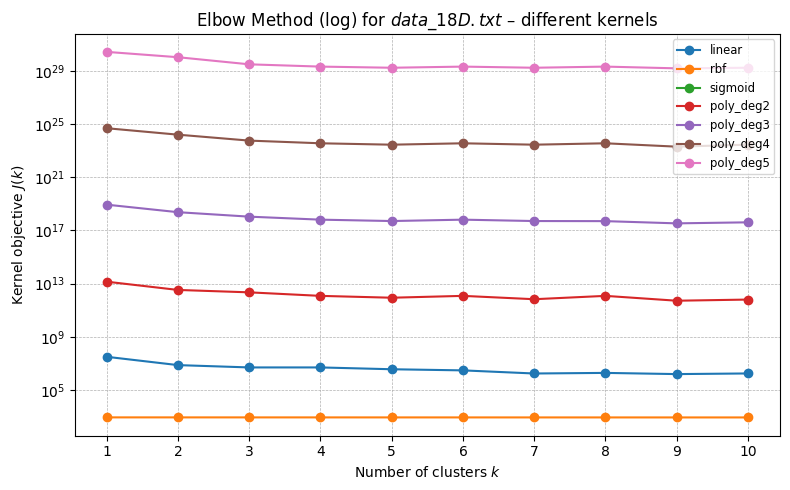

In [ ]:
plt.figure(figsize=(8, 5))
ks = np.arange(1, max_k + 1)

for key, J_vals in kernel_J.items():
    plt.plot(ks, J_vals, marker="o", label=key)

plt.xticks(ks)
plt.xlabel("Number of clusters $k$")
plt.ylabel("Kernel objective $J(k)$")
plt.yscale("log")
plt.title(r"Elbow Method (log) for $data\_18D.txt$ – different kernels")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()

In [ ]:
n_kernels = len(kernel_J)
ncols = 4
nrows = math.ceil(n_kernels / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), sharex=True)
axes = axes.flatten()

for idx, (key, J_vals) in enumerate(kernel_J.items()):
    ax = axes[idx]
    ax.plot(ks, J_vals, marker="o")
    ax.set_xticks(ks)
    ax.set_xlabel("Number of clusters $k$")
    ax.set_ylabel("Kernel objective $J(k)$")
    ax.set_title(rf"Elbow for $dane\_18D.txt$ – {key}")
    ax.grid(True, ls="--", lw=0.5)

for idx in range(n_kernels, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
fig.savefig("elbow_all_kernels.png")
plt.close(fig)

Hierarchical


In [ ]:
def hierarchical_clustering(X, n_clusters, method):
    m = X.shape[0]
    D = cdist(X, X)
    np.fill_diagonal(D, np.inf)

    cluster_sizes = np.ones(m, dtype=int)

    active = np.ones(m, dtype=bool)

    cluster_map = np.arange(m, dtype=int)

    current_k = m

    while current_k > n_clusters:
        mask = np.logical_and(active[:, None], active[None, :])
        D_masked = np.where(mask, D, np.inf)

        idx_min = np.argmin(D_masked)
        i = idx_min // m
        j = idx_min % m
        if j < i:
            i, j = j, i

        size_i = cluster_sizes[i]
        size_j = cluster_sizes[j]

        cluster_sizes[i] = size_i + size_j
        active[j] = False

        cluster_map[cluster_map == j] = i

        for k in range(m):
            if not active[k] or k == i:
                continue

            if method == "single":
                D[i, k] = min(D[i, k], D[j, k])
                D[k, i] = D[i, k]

            elif method == "complete":
                D[i, k] = max(D[i, k], D[j, k])
                D[k, i] = D[i, k]

            elif method == "average":
                D[i, k] = (size_i * D[i, k] + size_j * D[j, k]) / (size_i + size_j)
                D[k, i] = D[i, k]

            elif method == "ward":
                size_k = cluster_sizes[k]
                d_ij = D[i, j]
                d_i_k = D[i, k]
                d_j_k = D[j, k]
                new_d = (
                    (size_i + size_k) * d_i_k
                    + (size_j + size_k) * d_j_k
                    - size_k * d_ij
                ) / (size_i + size_j + size_k)
                D[i, k] = new_d
                D[k, i] = new_d

            else:
                raise ValueError(f"Nieznana metoda: {method}")

        D[j, :] = np.inf
        D[:, j] = np.inf

        current_k -= 1

    unique_ids = np.unique(cluster_map[np.isin(cluster_map, np.where(active)[0])])
    new_label = {old: new for new, old in enumerate(unique_ids)}
    final_labels = np.array([new_label[c] for c in cluster_map], dtype=int)

    return final_labels

In [ ]:
linkage_methods = ["single", "complete", "average", "ward"]

In [ ]:
for n in range(1, 9):
    filename = f"dane/dane_2D_{n}.txt"
    df = pd.read_csv(filename, sep=r"\s+", header=None, names=["x", "y", "class"])
    X = df[["x", "y"]].values
    true_classes = df["class"].values
    n_clusters = len(np.unique(true_classes))

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    for i, method in enumerate(linkage_methods):
        labels_hier = hierarchical_clustering(X, n_clusters, method)
        err = clustering_error(true_classes, labels_hier)

        print(f"dane_2D_{n} | method={method} Classification error rate: {err:.4f}")
        ax = axes[i]
        for k in range(n_clusters):
            pts = X[labels_hier == k]
            ax.scatter(pts[:, 0], pts[:, 1], label=f"Cluster {k}")
        ax.set_title(f"Method: {method}\nClassification error rate = {err:.3f}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.grid(True)

    plt.suptitle(f"Hierarchical clustering for dane_2D_{n}.txt", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    output_filename = f"hierarchical_dane_2D_{n}.png"
    plt.savefig(output_filename)
    plt.close()
    print(f"dane_2D_{n} | saved: {output_filename}")

dane_2D_1 | method=single Classification error rate: 0.1726
dane_2D_1 | method=complete Classification error rate: 0.0825
dane_2D_1 | method=average Classification error rate: 0.0038
dane_2D_1 | method=ward Classification error rate: 0.0457
dane_2D_1 | saved: hierarchical_dane_2D_1.png
dane_2D_2 | method=single Classification error rate: 0.2531
dane_2D_2 | method=complete Classification error rate: 0.1754
dane_2D_2 | method=average Classification error rate: 0.1253
dane_2D_2 | method=ward Classification error rate: 0.1654
dane_2D_2 | saved: hierarchical_dane_2D_2.png
dane_2D_3 | method=single Classification error rate: 0.6267
dane_2D_3 | method=complete Classification error rate: 0.3167
dane_2D_3 | method=average Classification error rate: 0.2700
dane_2D_3 | method=ward Classification error rate: 0.3000
dane_2D_3 | saved: hierarchical_dane_2D_3.png
dane_2D_4 | method=single Classification error rate: 0.0000
dane_2D_4 | method=complete Classification error rate: 0.6218
dane_2D_4 | metho

In [ ]:
df_rp = pd.read_csv(
    "dane/rp.data",
    header=None,
    sep=r"\s+",
    names=[f"f{i}" for i in range(1, 10)] + ["class"],
)
X_rp = df_rp.iloc[:, :-1].values
true_classes_rp = df_rp["class"].values
n_clusters_rp = len(np.unique(true_classes_rp))

for method in linkage_methods:
    labels_rp = hierarchical_clustering(X_rp, n_clusters_rp, method)
    err_rp = clustering_error(true_classes_rp, labels_rp)
    print(f"Method: {method:8s} Classification error rate: {err_rp:.4f}")

Method: single   Classification error rate: 0.3485
Method: complete Classification error rate: 0.1142
Method: average  Classification error rate: 0.0571
Method: ward     Classification error rate: 0.0366


In [ ]:
def compute_sse_hierarchical(X, labels):
    sse = 0.0
    for c in np.unique(labels):
        pts = X[labels == c]
        mu = pts.mean(axis=0)
        sse += np.sum((pts - mu) ** 2)
    return sse

In [ ]:
max_k_hier = 10

hier_SSE = {}

for method in linkage_methods:
    SSE_vals = []
    for k in range(1, max_k_hier + 1):
        labels_h = hierarchical_clustering(X18, k, method)
        sse_k = compute_sse_hierarchical(X18, labels_h)
        SSE_vals.append(sse_k)
    hier_SSE[method] = SSE_vals

ks_hier = np.arange(1, max_k_hier + 1)

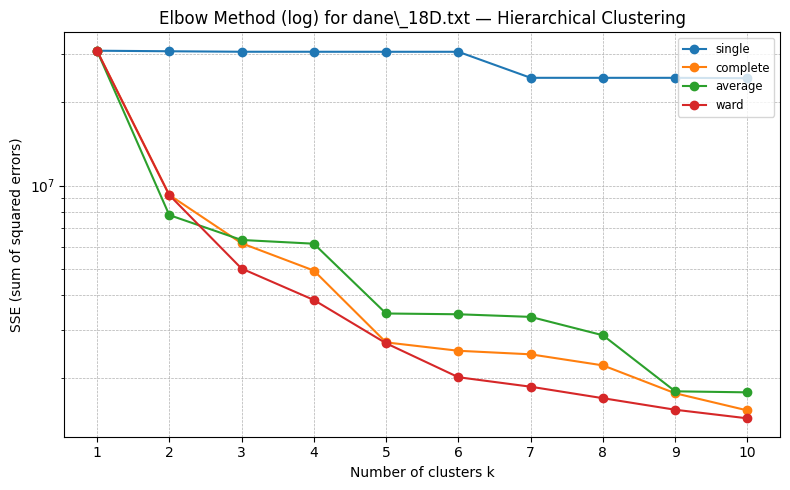

In [ ]:
plt.figure(figsize=(8, 5))
for method, SSE_vals in hier_SSE.items():
    plt.plot(ks_hier, SSE_vals, marker="o", label=method)
plt.xticks(ks_hier)
plt.xlabel("Number of clusters k")
plt.ylabel("SSE (sum of squared errors)")
plt.yscale("log")
plt.title(r"Elbow Method (log) for dane\_18D.txt — Hierarchical Clustering")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend(loc="upper right", fontsize="small")
plt.tight_layout()
plt.show()

In [ ]:
n_methods = len(linkage_methods)
ncols_h = 2
nrows_h = math.ceil(n_methods / ncols_h)
fig, axes_h = plt.subplots(
    nrows_h, ncols_h, figsize=(4 * ncols_h, 3 * nrows_h), sharex=True
)
axes_h = axes_h.flatten()

for idx, method in enumerate(linkage_methods):
    ax = axes_h[idx]
    SSE_vals = hier_SSE[method]
    ax.plot(ks_hier, SSE_vals, marker="o")
    ax.set_xticks(ks_hier)
    ax.set_xlabel("Number of clusters k")
    ax.set_ylabel("SSE (log)")
    ax.set_yscale("log")
    ax.set_title(rf"Elbow for $dane\_18D.txt$ — {method}")
    ax.grid(True, ls="--", lw=0.5)

for idx in range(n_methods, len(axes_h)):
    axes_h[idx].axis("off")

plt.tight_layout()
fig.savefig("elbow_hierarchical_18D.png")
plt.close(fig)

Spektralna


In [26]:
def adjacency_eps(X, eps, metric="euclidean", weighted=False, sigma=None):
    dist = cdist(X, X, metric=metric)
    A = (dist < eps).astype(float)
    if weighted:
        if sigma is None:
            sigma = np.median(dist[dist > 0])
        A *= np.exp(-(dist**2) / (2 * sigma**2))
    np.fill_diagonal(A, 0.0)
    return A

In [27]:
def adjacency_knn(X, k, metric="euclidean", symmetric=True, weighted=True, sigma=None):
    dist = cdist(X, X, metric=metric)
    idx = np.argsort(dist, axis=1)[:, 1 : k + 1]
    A = np.zeros_like(dist)
    rows = np.repeat(np.arange(X.shape[0]), k)
    A[rows, idx.flatten()] = 1.0
    if symmetric:
        A = np.maximum(A, A.T)
    if weighted:
        if sigma is None:
            sigma = np.median(dist[dist > 0])
        A *= np.exp(-(dist**2) / (2 * sigma**2))
    np.fill_diagonal(A, 0.0)
    return A

In [28]:
def adjacency_full(X, metric="euclidean", sigma=None):
    dist = cdist(X, X, metric=metric)
    if sigma is None:
        sigma = np.median(dist[dist > 0])
    A = np.exp(-(dist**2) / (2 * sigma**2))
    np.fill_diagonal(A, 0.0)
    return A

In [29]:
def spectral_clustering(A, n_clusters, normalized=True, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    degrees = A.sum(axis=1)
    L = np.diag(degrees) - A

    if normalized:
        with np.errstate(divide="ignore"):
            inv_sqrt = 1.0 / np.sqrt(np.where(degrees > 0, degrees, 1))
        D_inv_sqrt = np.diag(inv_sqrt)
        L = D_inv_sqrt @ L @ D_inv_sqrt

    eigvals, eigvecs = eigh(L)
    U = eigvecs[:, :n_clusters]

    if normalized:
        row_norms = np.linalg.norm(U, axis=1, keepdims=True)
        row_norms[row_norms == 0] = 1.0
        U = U / row_norms

    km = KMeansPP(
        n_clusters=n_clusters, max_iters=300, tol=1e-6, random_state=random_state
    )
    km.fit(U)
    return km.labels_

In [30]:
for n in range(1, 9):
    filename = f"dane/dane_2D_{n}.txt"
    df = pd.read_csv(filename, sep=r"\s+", header=None, names=["x", "y", "class"])
    X = df[["x", "y"]].values
    y_true = df["class"].values
    true_classes = len(np.unique(y_true))

    graphs = [
        ("eps_w", adjacency_eps(X, eps=0.25, weighted=True, sigma=0.4)),
        ("knn", adjacency_knn(X, k=8, weighted=True, sigma=0.4)),
        ("full", adjacency_full(X, sigma=0.4)),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes = axes.flatten()

    for i, (gname, A) in enumerate(graphs):
        labels = spectral_clustering(A, true_classes, normalized=True, random_state=42)
        err = clustering_error(y_true, labels)

        ax = axes[i]
        for k in range(true_classes):
            pts = X[labels == k]
            ax.scatter(pts[:, 0], pts[:, 1], label=f"Cl {k}")
        ax.set_title(f"{gname}  |  err={err:.3f}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.grid(True)

        print(
            f"dane_2D_{n} | spectral {gname:5s}  Classification error rate: {err:.4f}"
        )

    plt.suptitle(f"Spectral clustering — dane_2D_{n}.txt", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    out_png = f"spectral_dane_2D_{n}.png"
    plt.savefig(out_png, dpi=150)
    plt.close()
    print(f"saved: {out_png}")

dane_2D_1 | spectral eps_w  Classification error rate: 0.6459
dane_2D_1 | spectral knn    Classification error rate: 0.0495
dane_2D_1 | spectral full   Classification error rate: 0.0495
saved: spectral_dane_2D_1.png
dane_2D_2 | spectral eps_w  Classification error rate: 0.5915
dane_2D_2 | spectral knn    Classification error rate: 0.0802
dane_2D_2 | spectral full   Classification error rate: 0.0802
saved: spectral_dane_2D_2.png
dane_2D_3 | spectral eps_w  Classification error rate: 0.6333
dane_2D_3 | spectral knn    Classification error rate: 0.1767
dane_2D_3 | spectral full   Classification error rate: 0.1767
saved: spectral_dane_2D_3.png
dane_2D_4 | spectral eps_w  Classification error rate: 0.6571
dane_2D_4 | spectral knn    Classification error rate: 0.0000
dane_2D_4 | spectral full   Classification error rate: 0.0000
saved: spectral_dane_2D_4.png
dane_2D_5 | spectral eps_w  Classification error rate: 0.4829
dane_2D_5 | spectral knn    Classification error rate: 0.0277
dane_2D_5 | 

In [ ]:
df = pd.read_csv(
    "dane/rp.data",
    sep=r"\s+",
    header=None,
    names=[f"f{i}" for i in range(1, 10)] + ["class"],
)
X = df.iloc[:, :-1].values
y_pred = df["class"].values
true_classes = len(np.unique(y_pred))

graphs_rp = [
    ("full", adjacency_full(X, sigma=2.0)),
    ("eps_w", adjacency_eps(X, eps=4.0, weighted=True, sigma=2.0)),
    ("knn", adjacency_knn(X, k=12, weighted=True, sigma=2.0)),
]

for gname, A in graphs_rp:
    lbl = spectral_clustering(A, true_classes, normalized=True, random_state=42)
    err = clustering_error(y_pred, lbl)
    print(f"Method: {gname:5s}  Classification error rate: {err:.4f}")

rspectral full   Classification error rate: 0.0293
rspectral eps_w  Classification error rate: 0.3499
rspectral knn    Classification error rate: 0.0322


In [32]:
df = pd.read_csv("dane/data_18D.txt", sep=r"\s+", header=None)
X = df.values
ks = np.arange(1, 11)

In [33]:
def sse_original(X, labels):
    sse = 0.0
    for c in np.unique(labels):
        pts = X[labels == c]
        mu = pts.mean(axis=0)
        sse += np.sum((pts - mu) ** 2)
    return sse


In [34]:
graphs_rp = [
    ("full", adjacency_full(X, sigma=2.0)),
    ("eps_w", adjacency_eps(X, eps=4.0, weighted=True, sigma=2.0)),
    ("knn", adjacency_knn(X, k=12, weighted=True, sigma=2.0)),
]

colors = {"full": "tab:blue", "eps_w": "tab:green", "knn": "tab:red"}
all_sse = {}

for name, A in graphs_rp:
    sse_vals = []
    for k in ks:
        lbl = spectral_clustering(A, k, normalized=True, random_state=42)
        sse_k = sse_original(X, lbl)
        sse_vals.append(sse_k)
        print(f"{name:>5s}  k={k:2d}  SSE = {sse_k:.6e}")
    
    all_sse[name] = sse_vals
    
    plt.figure(figsize=(7, 4))
    plt.plot(ks, sse_vals, marker="o", label=name)
    plt.xticks(ks)
    plt.yscale("log")
    plt.xlabel("Number of clusters k")
    plt.ylabel("SSE (log)")
    plt.title(f"Elbow – spectral clustering, graph={name}, data_18D.txt")
    plt.grid(True, ls="--", lw=0.5)
    plt.tight_layout()
    fname = f"spectral_elbow_18D_{name}.png"
    plt.savefig(fname, dpi=150)
    plt.close()
    print(f"saved: {fname}")

plt.figure(figsize=(8, 5))
for name in all_sse:
    plt.plot(ks, all_sse[name], marker="o", label=name, color=colors[name])
plt.xticks(ks)
plt.yscale("log")
plt.xlabel("Number of clusters k")
plt.ylabel("SSE (log)")
plt.title("Elbow comparison – spectral clustering, data_18D.txt")
plt.grid(True, ls="--", lw=0.5)
plt.legend(title="Graph type")
plt.tight_layout()
plt.savefig("spectral_elbow_18D_combined.png", dpi=150)
plt.close()
print("saved: spectral_elbow_18D_combined.png")


 full  k= 1  SSE = 3.080921e+07
 full  k= 2  SSE = 3.048327e+07
 full  k= 3  SSE = 2.980241e+07
 full  k= 4  SSE = 2.748530e+07
 full  k= 5  SSE = 2.171914e+07
 full  k= 6  SSE = 2.041253e+07
 full  k= 7  SSE = 2.488858e+07
 full  k= 8  SSE = 1.817301e+07
 full  k= 9  SSE = 1.823437e+07
 full  k=10  SSE = 1.673582e+07
saved: spectral_elbow_18D_full.png
eps_w  k= 1  SSE = 3.080921e+07
eps_w  k= 2  SSE = 3.079520e+07
eps_w  k= 3  SSE = 3.075949e+07
eps_w  k= 4  SSE = 3.073817e+07
eps_w  k= 5  SSE = 3.071325e+07
eps_w  k= 6  SSE = 3.042705e+07
eps_w  k= 7  SSE = 3.040585e+07
eps_w  k= 8  SSE = 3.039869e+07
eps_w  k= 9  SSE = 3.037098e+07
eps_w  k=10  SSE = 3.031311e+07
saved: spectral_elbow_18D_eps_w.png
  knn  k= 1  SSE = 3.080921e+07
  knn  k= 2  SSE = 3.071548e+07
  knn  k= 3  SSE = 3.074237e+07
  knn  k= 4  SSE = 2.922410e+07
  knn  k= 5  SSE = 2.287381e+07
  knn  k= 6  SSE = 2.351023e+07
  knn  k= 7  SSE = 2.171457e+07
  knn  k= 8  SSE = 2.287842e+07
  knn  k= 9  SSE = 2.285709e+07
 